# Stage 4: Validation and Fitting

## Goal:

This notebook tests wether the model-fitting procedure is meaningful before applying it to real empirical data. 

We:
1. Simulate network activity using known ground-truth values of *K* and *lambda*
2. Add measurement noise
3. Compute a synthetic empirical PLI matrix
4. Fit K and lambda by maximising Pearson correlation
5. Visualise the fit quality and parameter recovery

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.signal import hilbert, butter, filtfilt
from scipy.stats import pearsonr


In [2]:
# -----------------------------
# Hopf model
# -----------------------------

def hopf_rhs(_t, state, _N, W, K, lam, C, omega):
    """
    Coupled Hopf oscillator ODE.
    State vector is [x1, y1, x2, y2, ..., xN, yN].
    """
    x = state[0::2]
    y = state[1::2]

    r2 = x**2 + y**2

    dx = x * (lam - r2) - omega * y + K * np.tanh(C * (W @ x))
    dy = y * (lam - r2) + omega * x

    out = np.empty_like(state)
    out[0::2] = dx
    out[1::2] = dy
    return out


def random_initial_conditions(N, rng=None, scale=0.1):
    """
    Random complex initial conditions for N nodes.
    """
    rng = np.random.default_rng(rng)
    return scale * (rng.standard_normal(N) + 1j * rng.standard_normal(N))


def simulate_hopf(N, W, K, lam, C, omega, z0=None,
                  t_total=20.0, t_discard=5.0, fs=250):
    """
    Simulate coupled Hopf oscillators.

    Returns
    -------
    t : array, shape (T,)
    x : array, shape (N, T)
    y : array, shape (N, T)
    """
    if z0 is None:
        z0 = random_initial_conditions(N, rng=42)
    elif np.isscalar(z0):
        z0 = np.full(N, z0, dtype=complex)

    state0 = np.empty(2 * N)
    state0[0::2] = np.real(z0)
    state0[1::2] = np.imag(z0)

    t_eval = np.arange(0.0, t_total, 1.0 / fs)

    sol = solve_ivp(
        hopf_rhs,
        t_span=(0.0, t_total),
        y0=state0,
        t_eval=t_eval,
        args=(N, W, K, lam, C, omega),
        rtol=1e-6,
        atol=1e-8,
    )

    state = sol.y
    x = state[0::2]
    y = state[1::2]
    t = sol.t

    keep = t >= t_discard
    return t[keep], x[:, keep], y[:, keep]

In [3]:
# -----------------------------
# Signal processing and PLI
# -----------------------------

def bandpass_filter(signals, fs, f_lo=8.0, f_hi=12.0, order=4):
    """
    Band-pass filter node signals.

    Parameters
    ----------
    signals : array, shape (N, T)
    fs : float
        Sampling frequency
    """
    nyq = 0.5 * fs
    b, a = butter(order, [f_lo / nyq, f_hi / nyq], btype="band")
    return filtfilt(b, a, signals, axis=1)


def compute_pli(signals):
    """
    Compute Phase Lag Index (PLI) matrix from node signals.

    Parameters
    ----------
    signals : array, shape (N, T)

    Returns
    -------
    pli : array, shape (N, N)
    """
    phases = np.angle(hilbert(signals, axis=1))
    N = signals.shape[0]
    pli = np.zeros((N, N))

    for i in range(N):
        for j in range(i + 1, N):
            dphi = phases[i] - phases[j]
            pli_ij = np.abs(np.mean(np.sign(np.sin(dphi))))
            pli[i, j] = pli_ij
            pli[j, i] = pli_ij

    return pli


def upper_triangle_values(mat):
    """
    Return the upper-triangle values of a symmetric matrix, excluding diagonal.
    """
    iu = np.triu_indices_from(mat, k=1)
    return mat[iu]

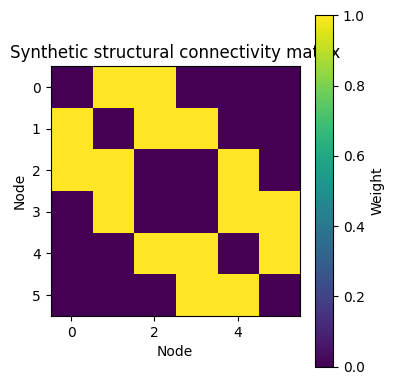

In [4]:
# -----------------------------
# Small synthetic test network
# -----------------------------

N = 6

W = np.array([
    [0, 1, 1, 0, 0, 0],
    [1, 0, 1, 1, 0, 0],
    [1, 1, 0, 0, 1, 0],
    [0, 1, 0, 0, 1, 1],
    [0, 0, 1, 1, 0, 1],
    [0, 0, 0, 1, 1, 0],
], dtype=float)

W = W / W.max()

omega_hz = 10.0
omega = 2 * np.pi * omega_hz * np.ones(N)

fs = 250
t_total = 20.0
t_discard = 5.0
C = 1.0

z0 = random_initial_conditions(N, rng=42)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(W, cmap="viridis")
ax.set_title("Synthetic structural connectivity matrix")
ax.set_xlabel("Node")
ax.set_ylabel("Node")
plt.colorbar(im, ax=ax, label="Weight")
fig.tight_layout()

In [5]:
# -----------------------------
# Generate synthetic empirical PLI
# -----------------------------

def generate_synthetic_empirical_pli(N, W, K_true, lam_true, C, omega, z0,
                                     t_total=20.0, t_discard=5.0, fs=250,
                                     noise_std=0.05, f_lo=8.0, f_hi=12.0):
    """
    Generate synthetic empirical PLI by:
    1. simulating the model with known parameters
    2. adding measurement noise
    3. filtering the noisy signals
    4. computing the PLI matrix
    """
    t, x, y = simulate_hopf(
        N=N, W=W, K=K_true, lam=lam_true, C=C,
        omega=omega, z0=z0,
        t_total=t_total, t_discard=t_discard, fs=fs,
    )

    noisy_x = x + noise_std * np.random.randn(*x.shape)
    filtered_x = bandpass_filter(noisy_x, fs=fs, f_lo=f_lo, f_hi=f_hi)
    pli_emp = compute_pli(filtered_x)

    return t, noisy_x, filtered_x, pli_emp

Ground-truth parameters: K = 0.800, lambda = 1.000


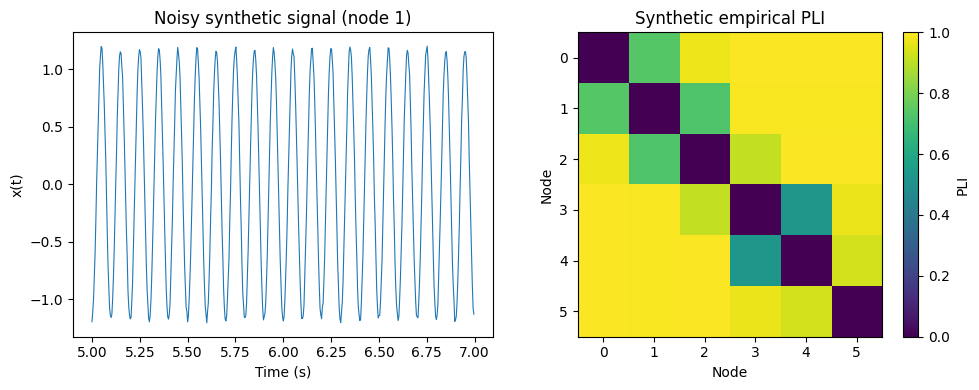

In [36]:
K_true = 0.8
lam_true = 1.0

t_emp, x_emp_noisy, x_emp_filt, pli_emp = generate_synthetic_empirical_pli(
    N=N, W=W, K_true=K_true, lam_true=lam_true, C=C,
    omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
    noise_std=0.02,
)

print(f"Ground-truth parameters: K = {K_true:.3f}, lambda = {lam_true:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(t_emp[:500], x_emp_noisy[0, :500], lw=0.8)
axes[0].set_title("Noisy synthetic signal (node 1)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("x(t)")

im = axes[1].imshow(pli_emp, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Synthetic empirical PLI")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Node")

plt.colorbar(im, ax=axes[1], label="PLI")
fig.tight_layout()

In [24]:
# -----------------------------
# Fit K and lambda by grid search
# -----------------------------

def fit_k_lambda_grid(N, W, pli_emp, K_values, lam_values, C, omega, z0,
                      t_total=20.0, t_discard=5.0, fs=250,
                      f_lo=8.0, f_hi=12.0):
    """
    Grid search over K and lambda.
    For each parameter pair:
    1. simulate the network
    2. filter the simulated signals
    3. compute simulated PLI
    4. compare simulated PLI to synthetic empirical PLI with Pearson correlation

    Returns
    -------
    corr_map : array, shape (len(K_values), len(lam_values))
    best_corr : float
    best_params : tuple (K_best, lam_best)
    best_pli : array, shape (N, N)
    """
    emp_vals = upper_triangle_values(pli_emp)

    corr_map = np.zeros((len(K_values), len(lam_values)))
    best_corr = -np.inf
    best_params = None
    best_pli = None

    for i, K in enumerate(K_values):
        for j, lam in enumerate(lam_values):
            t, x, y = simulate_hopf(
                N=N, W=W, K=K, lam=lam, C=C,
                omega=omega, z0=z0,
                t_total=t_total, t_discard=t_discard, fs=fs,
            )

            filtered_x = bandpass_filter(x, fs=fs, f_lo=f_lo, f_hi=f_hi)
            pli_sim = compute_pli(filtered_x)

            sim_vals = upper_triangle_values(pli_sim)
            corr, _ = pearsonr(emp_vals, sim_vals)

            corr_map[i, j] = corr

            if corr > best_corr:
                best_corr = corr
                best_params = (K, lam)
                best_pli = pli_sim.copy()

    return corr_map, best_corr, best_params, best_pli

In [25]:
K_values = np.linspace(0.1, 1.5, 15)
lam_values = np.linspace(-0.5, 2.0, 15)

corr_map, best_corr, best_params, best_pli = fit_k_lambda_grid(
    N=N, W=W, pli_emp=pli_emp,
    K_values=K_values, lam_values=lam_values,
    C=C, omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
)

print(f"True parameters:      K = {K_true:.3f}, lambda = {lam_true:.3f}")
print(f"Recovered parameters: K = {best_params[0]:.3f}, lambda = {best_params[1]:.3f}")
print(f"Best correlation:     r = {best_corr:.3f}")

True parameters:      K = 0.800, lambda = 1.000
Recovered parameters: K = 0.800, lambda = 0.571
Best correlation:     r = 0.971


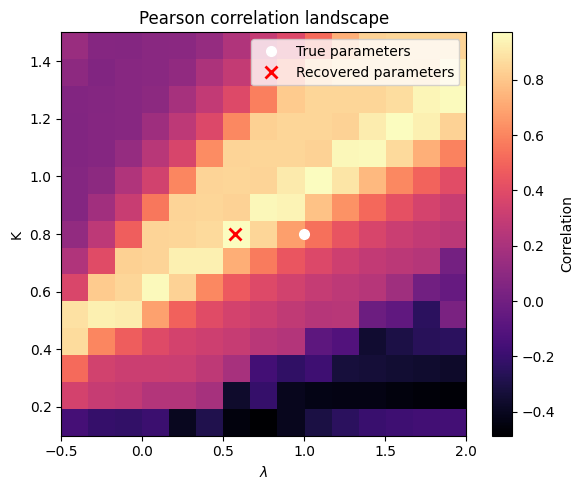

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    corr_map,
    origin="lower",
    aspect="auto",
    extent=[lam_values[0], lam_values[-1], K_values[0], K_values[-1]],
    cmap="magma",
)

ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("K")
ax.set_title("Pearson correlation landscape")

ax.plot(lam_true, K_true, "wo", ms=7, label="True parameters")
ax.plot(best_params[1], best_params[0], "rx", ms=8, mew=2, label="Recovered parameters")
ax.legend()

plt.colorbar(im, ax=ax, label="Correlation")
fig.tight_layout()

In [27]:
# -----------------------------
# Scatter plots: simulated vs empirical PLI
# -----------------------------

def plot_pli_scatter(pli_emp, pli_sim, title):
    emp_vals = upper_triangle_values(pli_emp)
    sim_vals = upper_triangle_values(pli_sim)
    r, _ = pearsonr(emp_vals, sim_vals)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(emp_vals, sim_vals, alpha=0.7)
    ax.set_xlabel("Synthetic empirical PLI")
    ax.set_ylabel("Simulated PLI")
    ax.set_title(f"{title}\nPearson r = {r:.3f}")

    lo = min(emp_vals.min(), sim_vals.min())
    hi = max(emp_vals.max(), sim_vals.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)

    fig.tight_layout()

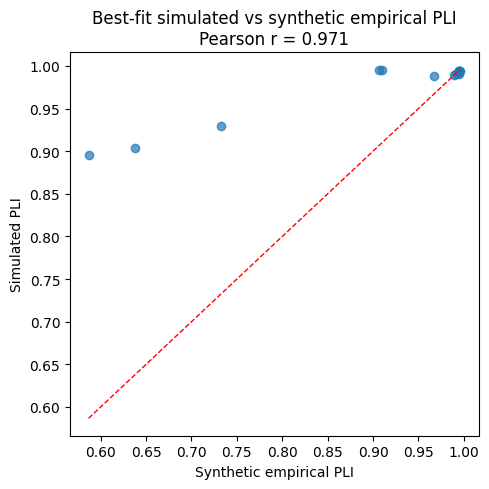

In [28]:
plot_pli_scatter(
    pli_emp, best_pli,
    title="Best-fit simulated vs synthetic empirical PLI"
)

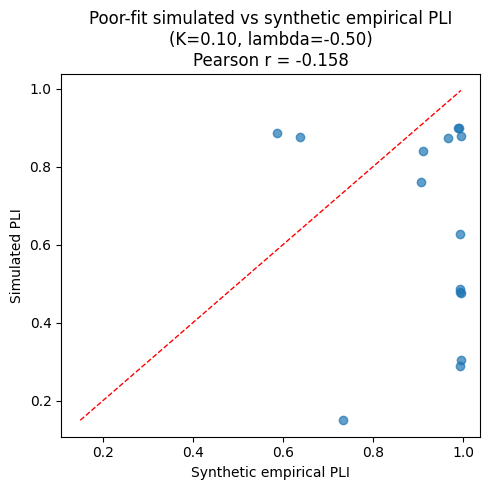

In [29]:
K_bad = K_values[0]
lam_bad = lam_values[0]

t_bad, x_bad, y_bad = simulate_hopf(
    N=N, W=W, K=K_bad, lam=lam_bad, C=C,
    omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
)

x_bad_filt = bandpass_filter(x_bad, fs=fs, f_lo=8.0, f_hi=12.0)
pli_bad = compute_pli(x_bad_filt)

plot_pli_scatter(
    pli_emp, pli_bad,
    title=f"Poor-fit simulated vs synthetic empirical PLI\n(K={K_bad:.2f}, lambda={lam_bad:.2f})"
)

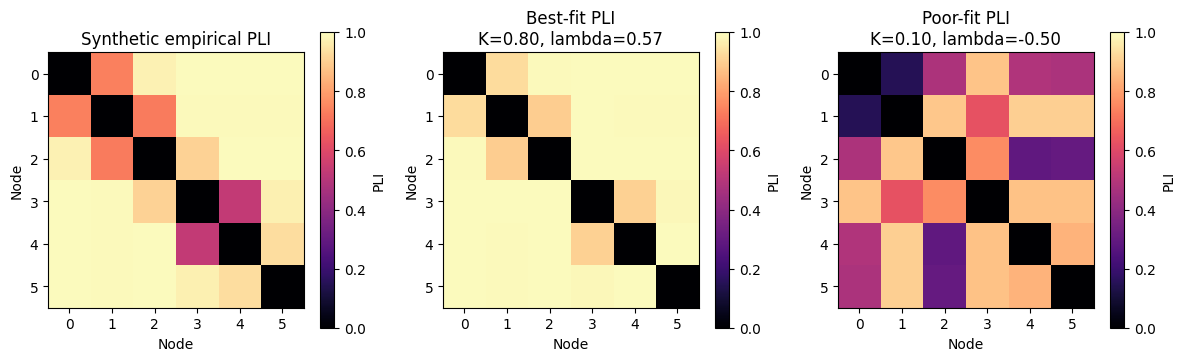

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(pli_emp, vmin=0, vmax=1, cmap="magma")
axes[0].set_title("Synthetic empirical PLI")
axes[0].set_xlabel("Node")
axes[0].set_ylabel("Node")

im1 = axes[1].imshow(best_pli, vmin=0, vmax=1, cmap="magma")
axes[1].set_title(f"Best-fit PLI\nK={best_params[0]:.2f}, lambda={best_params[1]:.2f}")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Node")

im2 = axes[2].imshow(pli_bad, vmin=0, vmax=1, cmap="magma")
axes[2].set_title(f"Poor-fit PLI\nK={K_bad:.2f}, lambda={lam_bad:.2f}")
axes[2].set_xlabel("Node")
axes[2].set_ylabel("Node")

plt.colorbar(im0, ax=axes[0], shrink=0.8, label="PLI")
plt.colorbar(im1, ax=axes[1], shrink=0.8, label="PLI")
plt.colorbar(im2, ax=axes[2], shrink=0.8, label="PLI")
plt.tight_layout()